In [ ]:
import pickle

import matplotlib.pyplot as plt
import torch
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm import tqdm

from sdoml_task1.config import PROJECT_DIR
from sdoml_task1.modeling.model import Net

In [ ]:
save_dir = PROJECT_DIR / "models"

with open(save_dir / "history.pkl", "rb") as f:
    history = pickle.load(f)


total_loss_train = history["total_loss_train"]
total_accuracy_train = history["total_accuracy_train"]
total_loss_valid = history["total_loss_valid"]
total_accuracy_valid = history["total_accuracy_valid"]
all_confusion_matrices = history["all_confusion_matrices"]
total_loss_train = history["total_loss_train"]
input_dim = history["input_dim"]

# Si tu veux aussi recharger le modèle pour l'utiliser (inférence, etc.)
net = Net(input_dim=input_dim)
net.load_state_dict(torch.load(save_dir / "model.pt", map_location="cpu"))
net.eval()

# torch.save(net.state_dict(), save_dir / "model.pt")

Net(
  (fc1): Linear(in_features=26, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

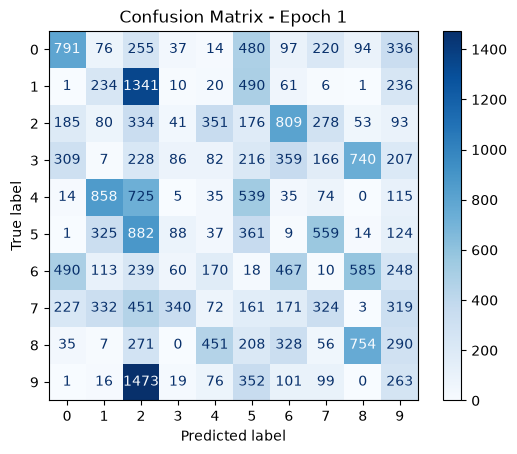

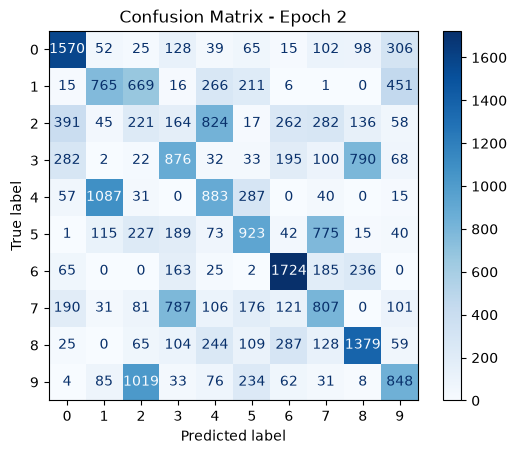

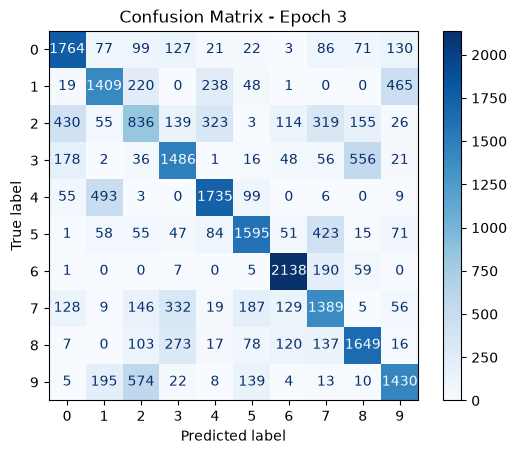

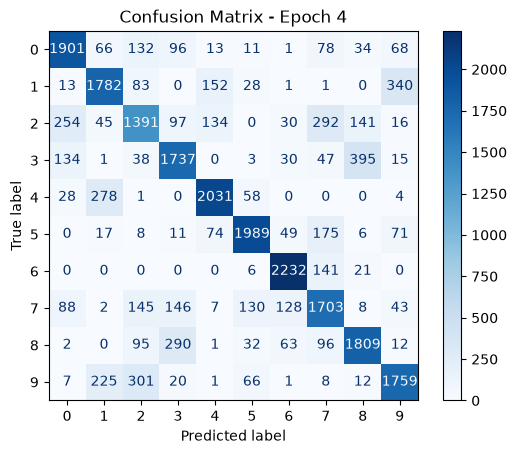

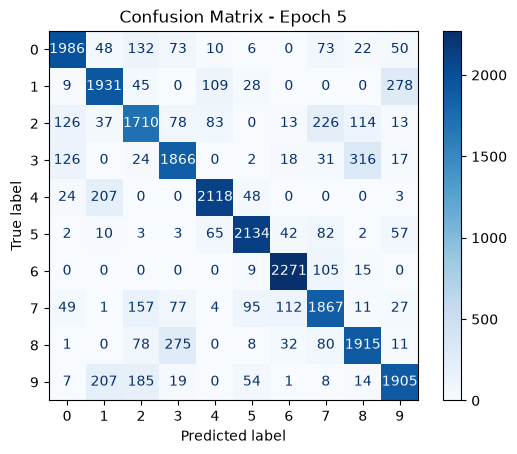

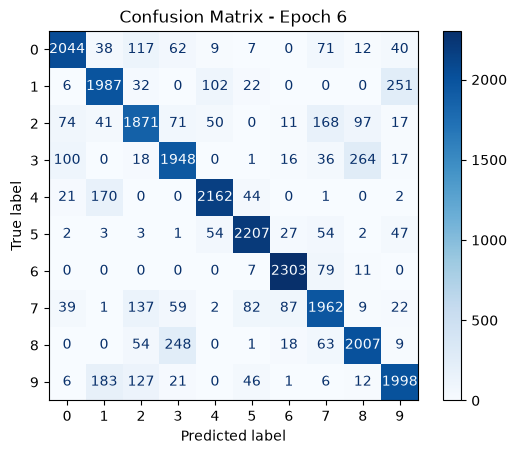

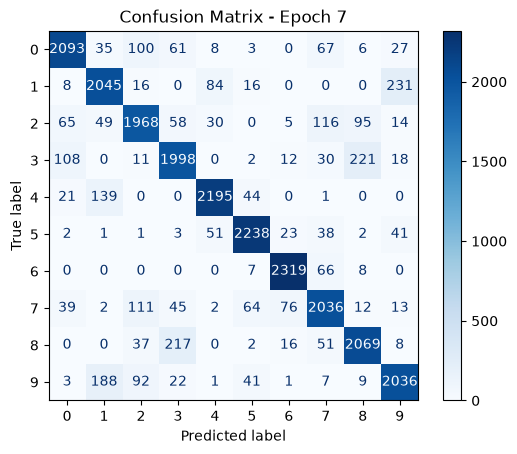

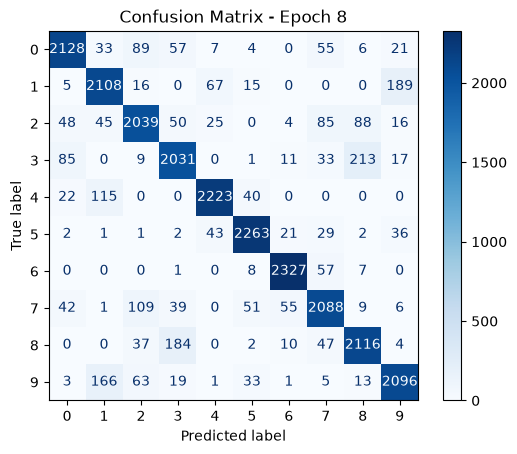

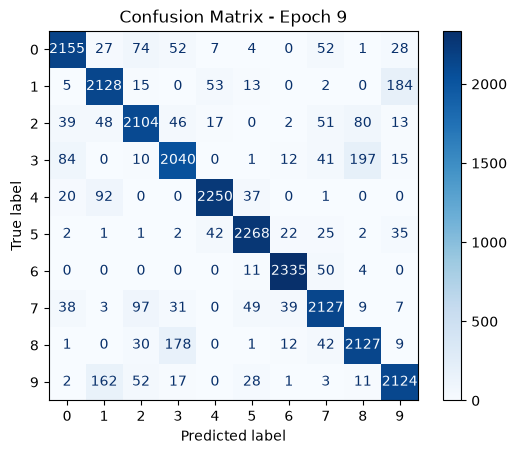

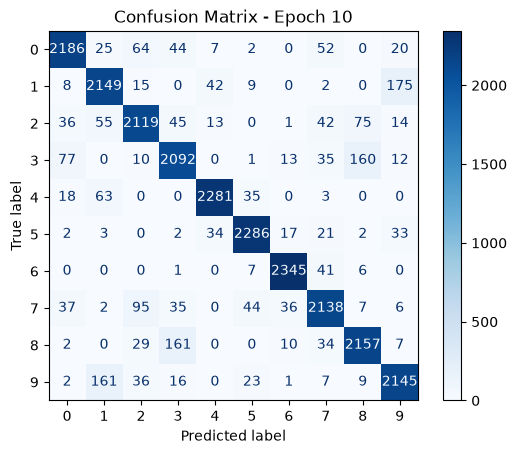

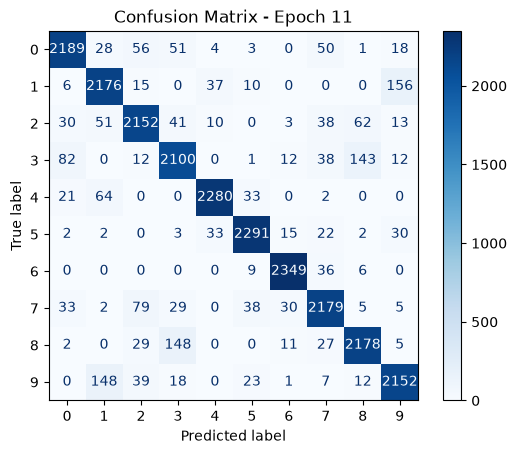

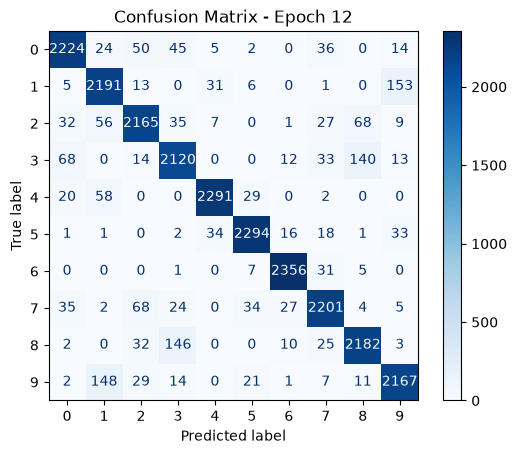

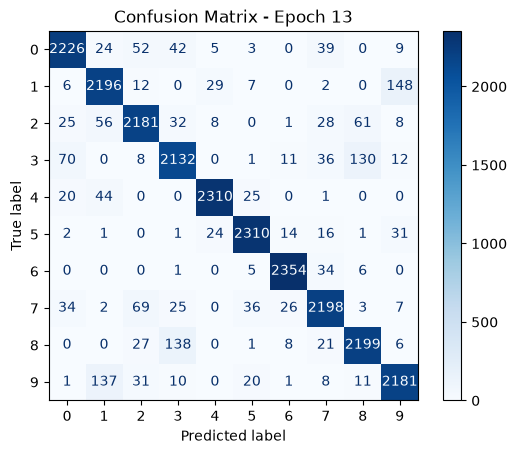

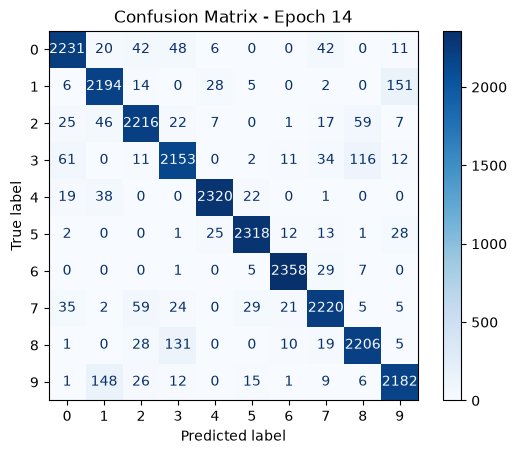

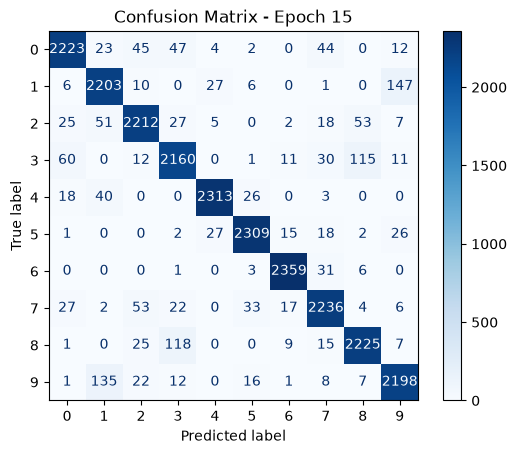

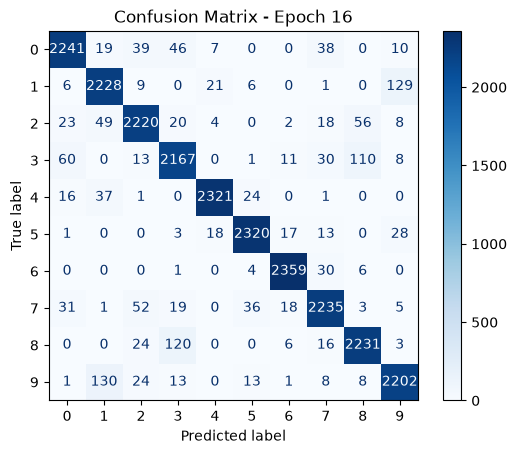

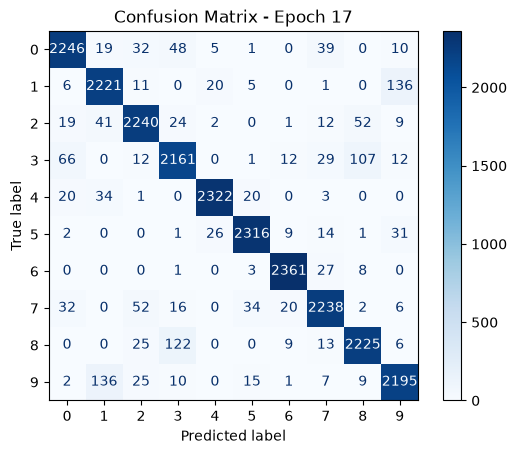

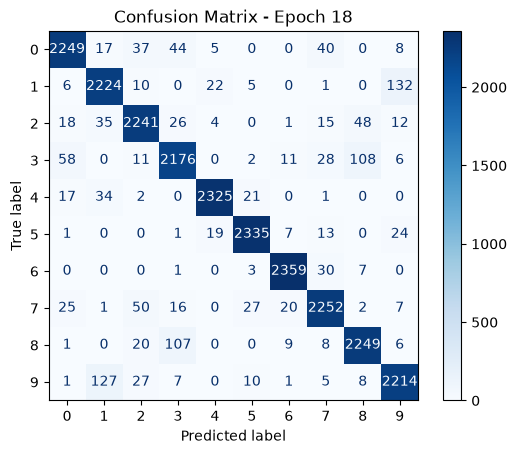

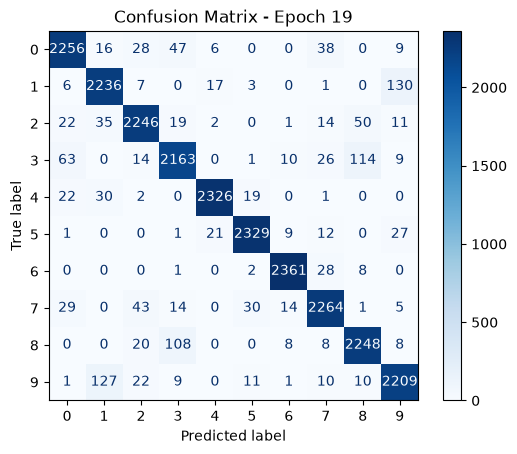

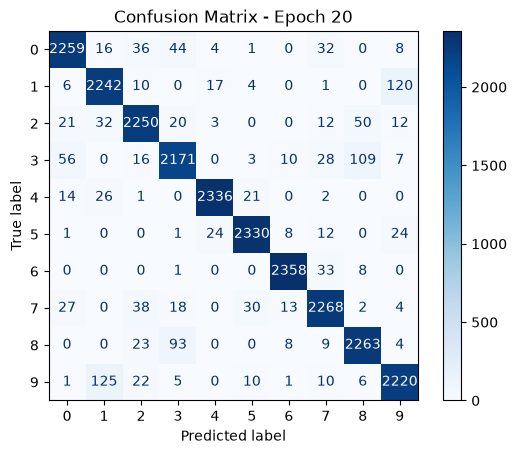

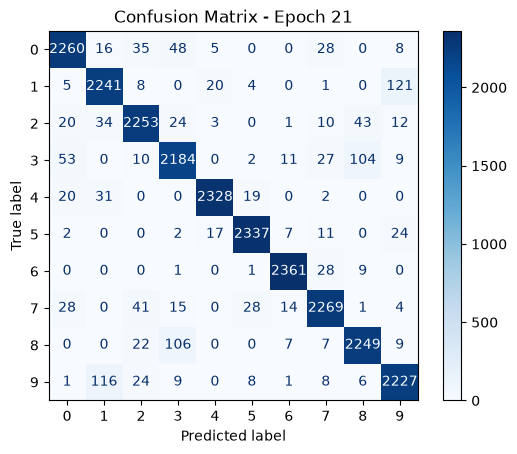

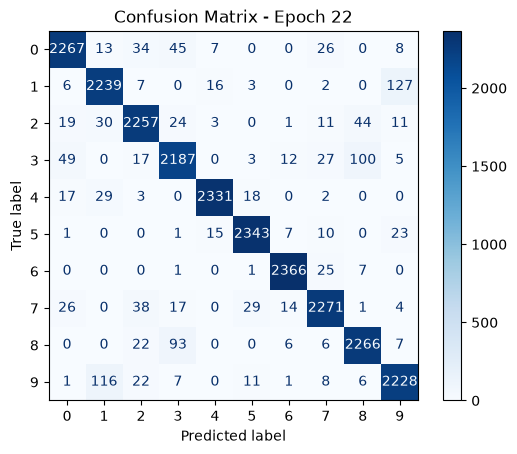

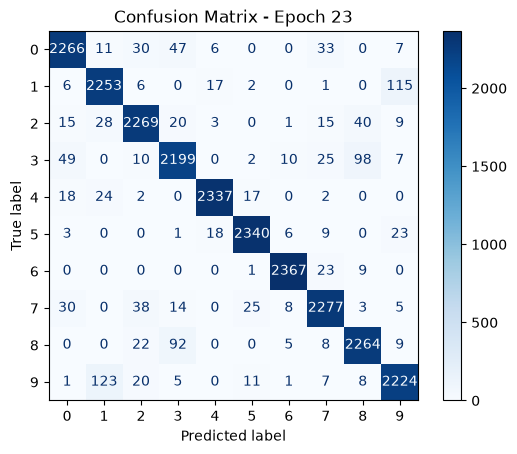

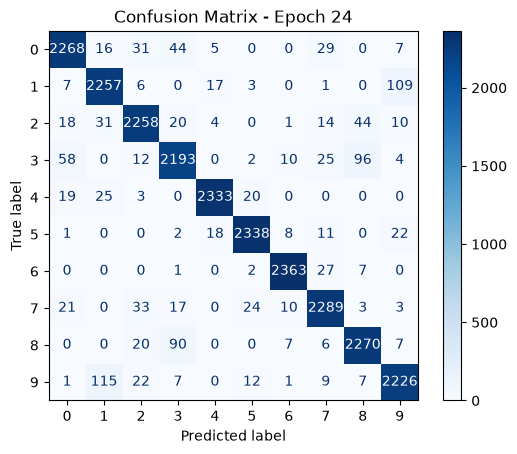

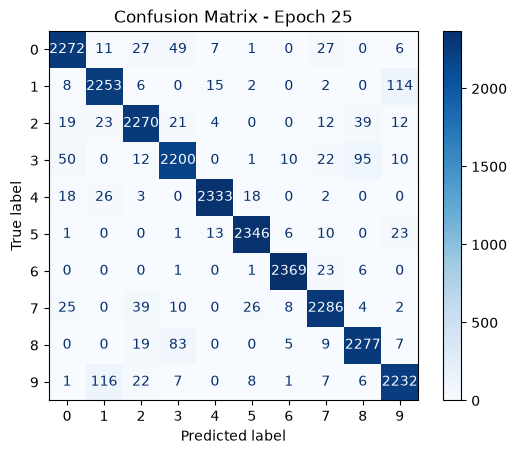

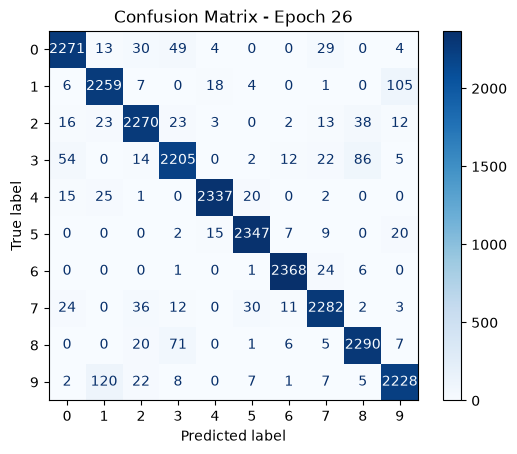

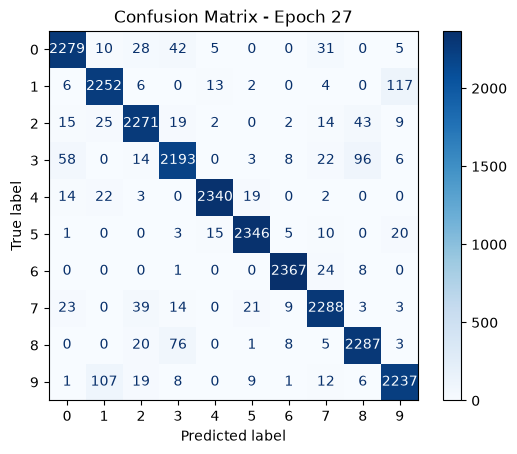

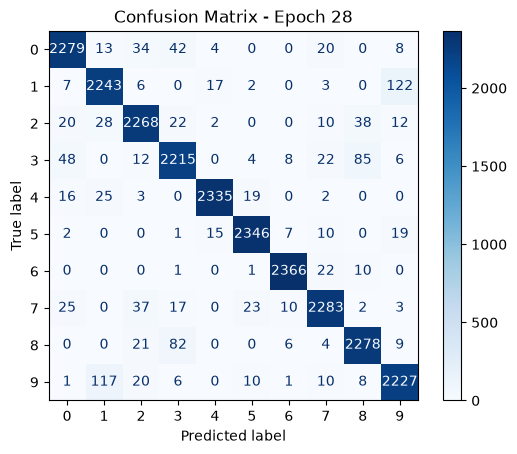

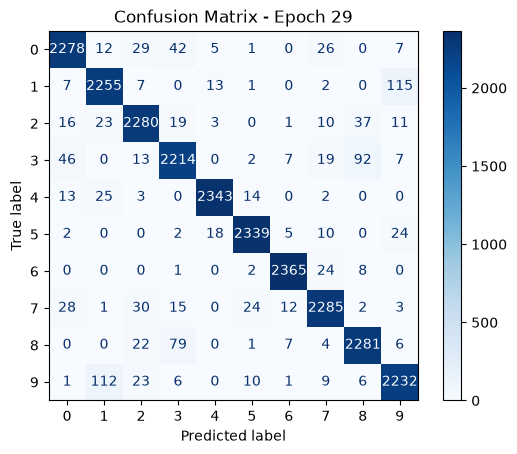

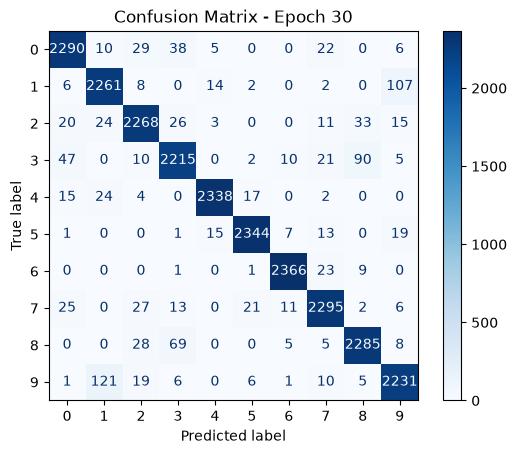

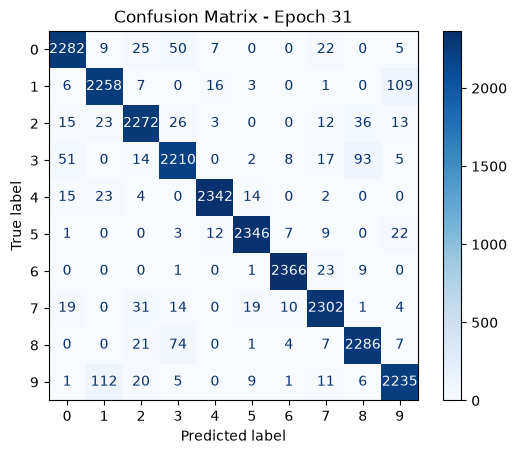

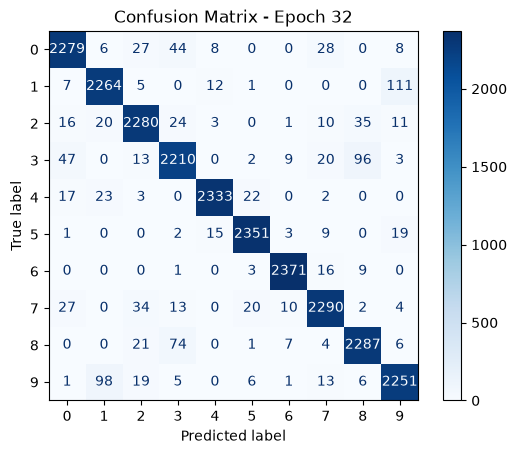

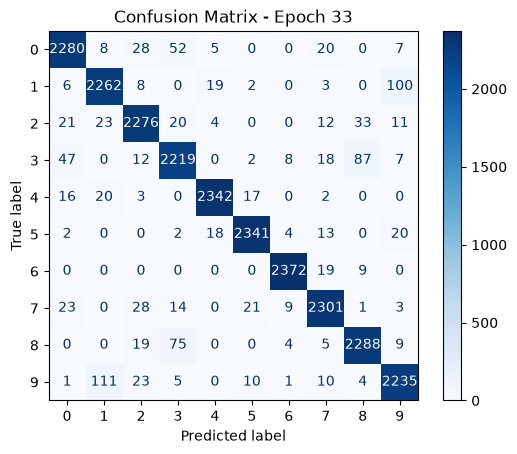

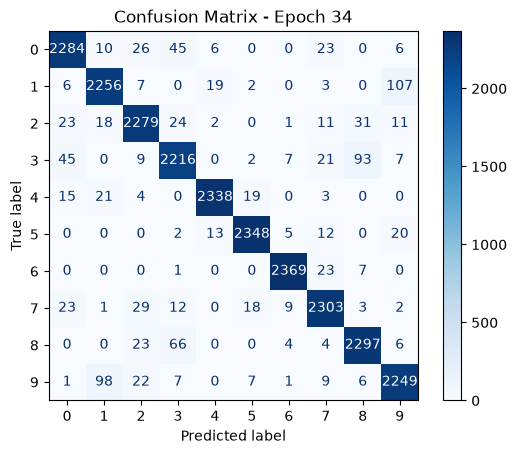

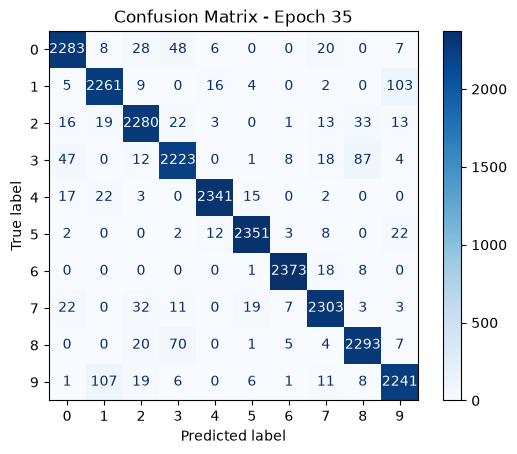

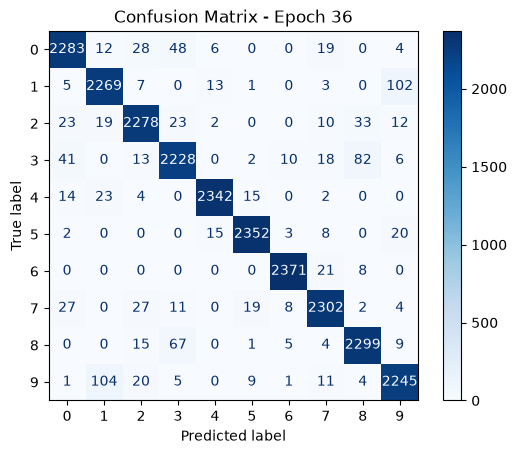

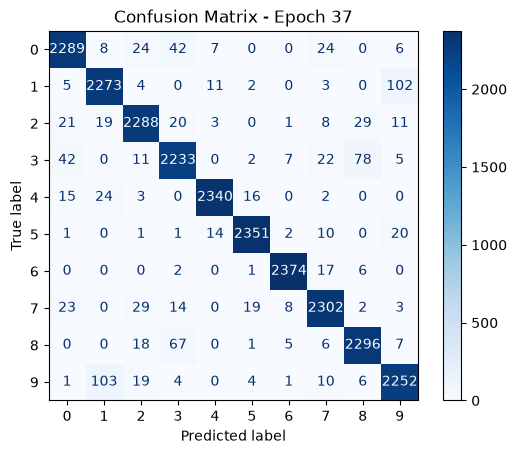

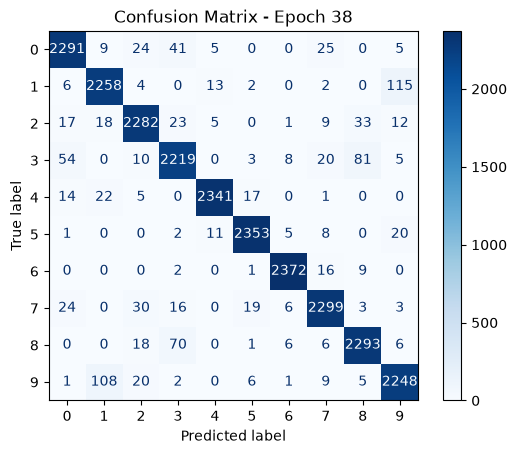

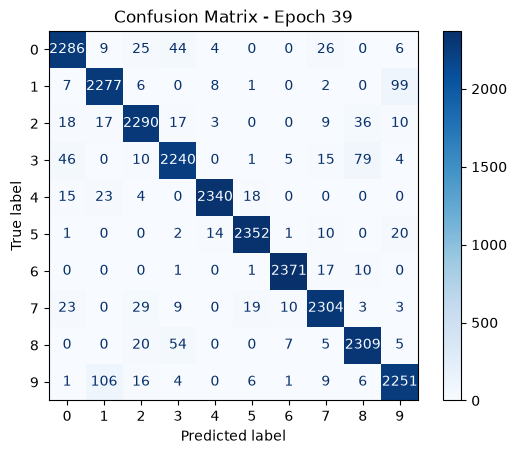

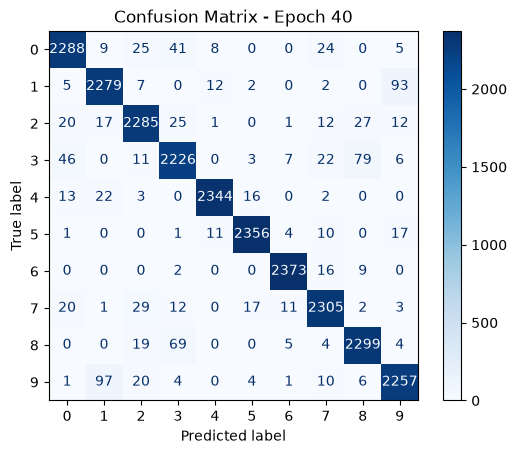

In [ ]:
for i, cm in enumerate(tqdm(all_confusion_matrices, desc="Generating confusion matrices")):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - Epoch {i+1}")
    plt.savefig(f"../assets/model_analysis/Confussion_Matrix_Epoch{i+1}.png", dpi=150)
    plt.close()
    print(f"")

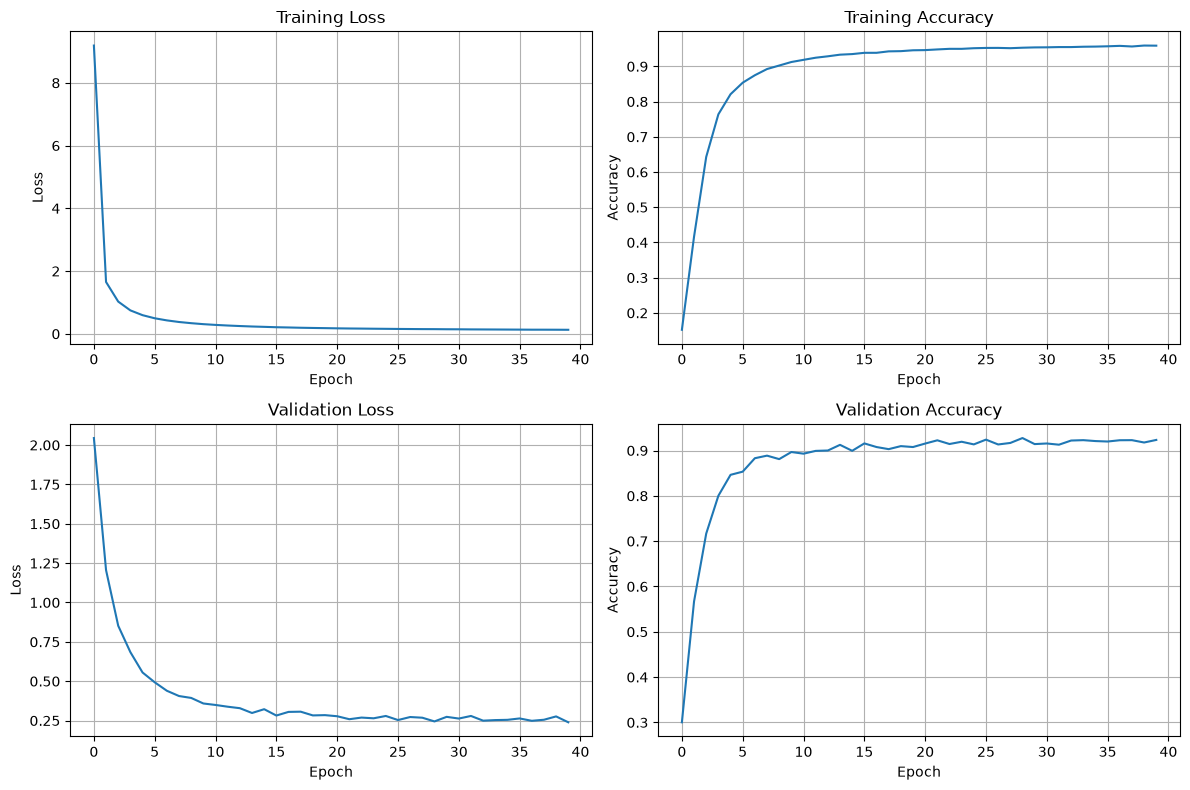

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axs.flatten()

ax1.plot(total_loss_train)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid()

ax2.plot(total_accuracy_train)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.grid()

ax3.plot(total_loss_valid)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.set_title('Validation Loss')
ax3.grid()

ax4.plot(total_accuracy_valid)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Validation Accuracy')  
ax4.grid()

plt.tight_layout()
plt.show()